# Assignment2 – dataset training

이 노트북은 `experiment_utils.py` 모듈을 사용합니다.  
실행 전 같은 디렉터리에 `experiment_utils.py` 가 있는지 확인하세요.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large"
).to(device)
print("BLIP model loaded")

/home/GenAI_202255597/miniconda3/envs/genai-assignment2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BLIP model loaded


In [4]:
from experiment_utils import (
    DATASET_CONFIGS,
    DEFAULT_LORA_RANK,
    DEFAULT_LORA_ALPHA,
    DEFAULT_EXPERIMENT_STEPS,
    NUM_IMAGES_PER_PROMPT,
    BASE_COMPARISON_DIR,
    BASE_DATASET_TRAINING_DIR,
    experiment_records,
    run_lora_training_experiment,
    generate_before_after_grid,
)
print("experiment_utils imported")

experiment_utils imported


In [5]:
RUN_FULL_EXPERIMENTS = True  # True로 변경하면 선택한 데이터셋 학습/생성 실험을 실행합니다.

# 학습할 데이터셋을 고릅니다. None이면 기존처럼 전체 데이터셋을 모두 실행합니다.
# 사용 가능한 이름: "web_crawled", "real", "generated"
SELECTED_DATASET_NAMES = ["generated"]

# 선택한 데이터셋의 기존 LoRA 결과를 삭제하고 새로 학습하려면 True로 바꿉니다.
RESET_SELECTED_OUTPUT_DIRS = True

if SELECTED_DATASET_NAMES is None:
    selected_dataset_configs = DATASET_CONFIGS
else:
    selected_dataset_configs = [
        dataset_config
        for dataset_config in DATASET_CONFIGS
        if dataset_config["name"] in SELECTED_DATASET_NAMES
    ]
    found_names = {dataset_config["name"] for dataset_config in selected_dataset_configs}
    missing_names = set(SELECTED_DATASET_NAMES) - found_names
    if missing_names:
        raise ValueError(f"Unknown dataset names: {sorted(missing_names)}")

print("Selected datasets:", [dataset_config["name"] for dataset_config in selected_dataset_configs])

Selected datasets: ['generated']


## Training LoRA on Selected Datasets

선택한 데이터셋에 대해 동일한 기본 LoRA 설정(`rank=4`, `alpha=4`)으로 학습합니다.

In [6]:
import shutil

dataset_lora_dirs = {}

if RUN_FULL_EXPERIMENTS:
    for dataset_config in selected_dataset_configs:
        output_subdir = f"rank{DEFAULT_LORA_RANK}_alpha{DEFAULT_LORA_ALPHA}"
        output_dir = os.path.join(
            BASE_DATASET_TRAINING_DIR, dataset_config["name"], output_subdir
        )
        if RESET_SELECTED_OUTPUT_DIRS and os.path.isdir(output_dir):
            shutil.rmtree(output_dir)
            print(f"Deleted existing output directory: {output_dir}")

        lora_dir = run_lora_training_experiment(
            dataset_config=dataset_config,
            processor=processor,
            blip_model=blip_model,
            device=device,
            lora_rank=DEFAULT_LORA_RANK,
            lora_alpha=DEFAULT_LORA_ALPHA,
            max_steps=DEFAULT_EXPERIMENT_STEPS,
            experiment_type="dataset_training",
        )
        dataset_lora_dirs[dataset_config["name"]] = lora_dir
else:
    print("Set RUN_FULL_EXPERIMENTS = True to train LoRA models for selected datasets.")

Deleted existing output directory: ./lora_experiments/dataset_training/generated/rank4_alpha4


Resolving data files: 100%|██████████| 21/21 [00:00<00:00, 111353.20it/s]
Generating train split: 20 examples [00:00, 4294.58 examples/s]


Loaded generated from ./data/generated_custom_dataset; metadata=./data/generated_custom_dataset/train/metadata.csv


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Launching training on one GPU.


Steps: 100%|██████████| 2000/2000 [33:50<00:00,  1.02s/it, lr=7.62e-11, step_loss=0.151] 


## Before / After Comparison

선택한 데이터셋별로 같은 prompt와 seed를 사용하여 base model 출력과 LoRA 적용 후 출력을 비교합니다.  
Grid의 첫 줄은 before, 둘째 줄은 after입니다.

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 17.71it/s]


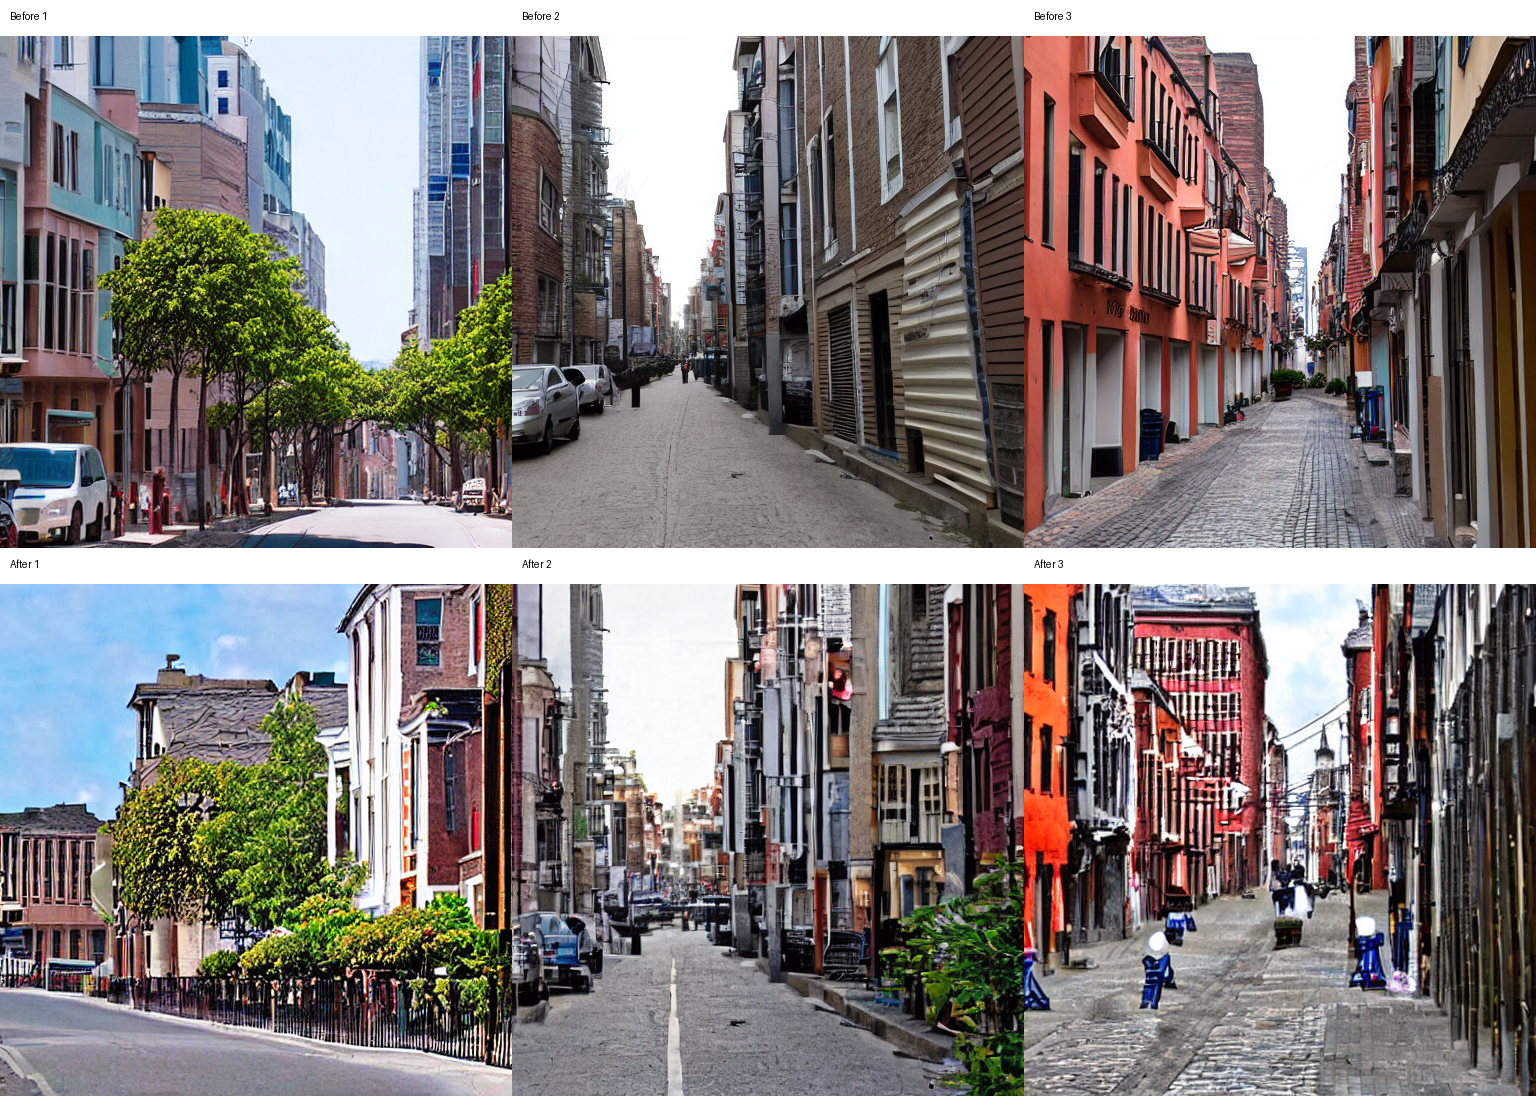

In [7]:
if RUN_FULL_EXPERIMENTS:
    for dataset_config in selected_dataset_configs:
        lora_dir = dataset_lora_dirs[dataset_config["name"]]
        result_image = os.path.join(
            BASE_COMPARISON_DIR, f"{dataset_config['name']}_before_after.png"
        )
        grid = generate_before_after_grid(
            dataset_config, lora_dir, result_image, device
        )
        display(grid)

        for record in experiment_records:
            if (
                record["experiment_type"] == "dataset_training"
                and record["dataset"] == dataset_config["name"]
                and record["output_dir"] == lora_dir
            ):
                record["result_image"] = result_image
else:
    print("Before/after comparison will run after RUN_FULL_EXPERIMENTS is enabled and training finishes.")